# "In-between" Uncertainty
This notebook runs IVON for a 1-100-100-2 MLP on a simple Gaussian regression problem. We will see that IVON can capture the uncertainty in regions where there is little data.

In [1]:
import ivon
import torch
import torch.optim
import math
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from torch import nn

mpl.rcParams['figure.dpi'] = 300

# Create and visualize the dataset

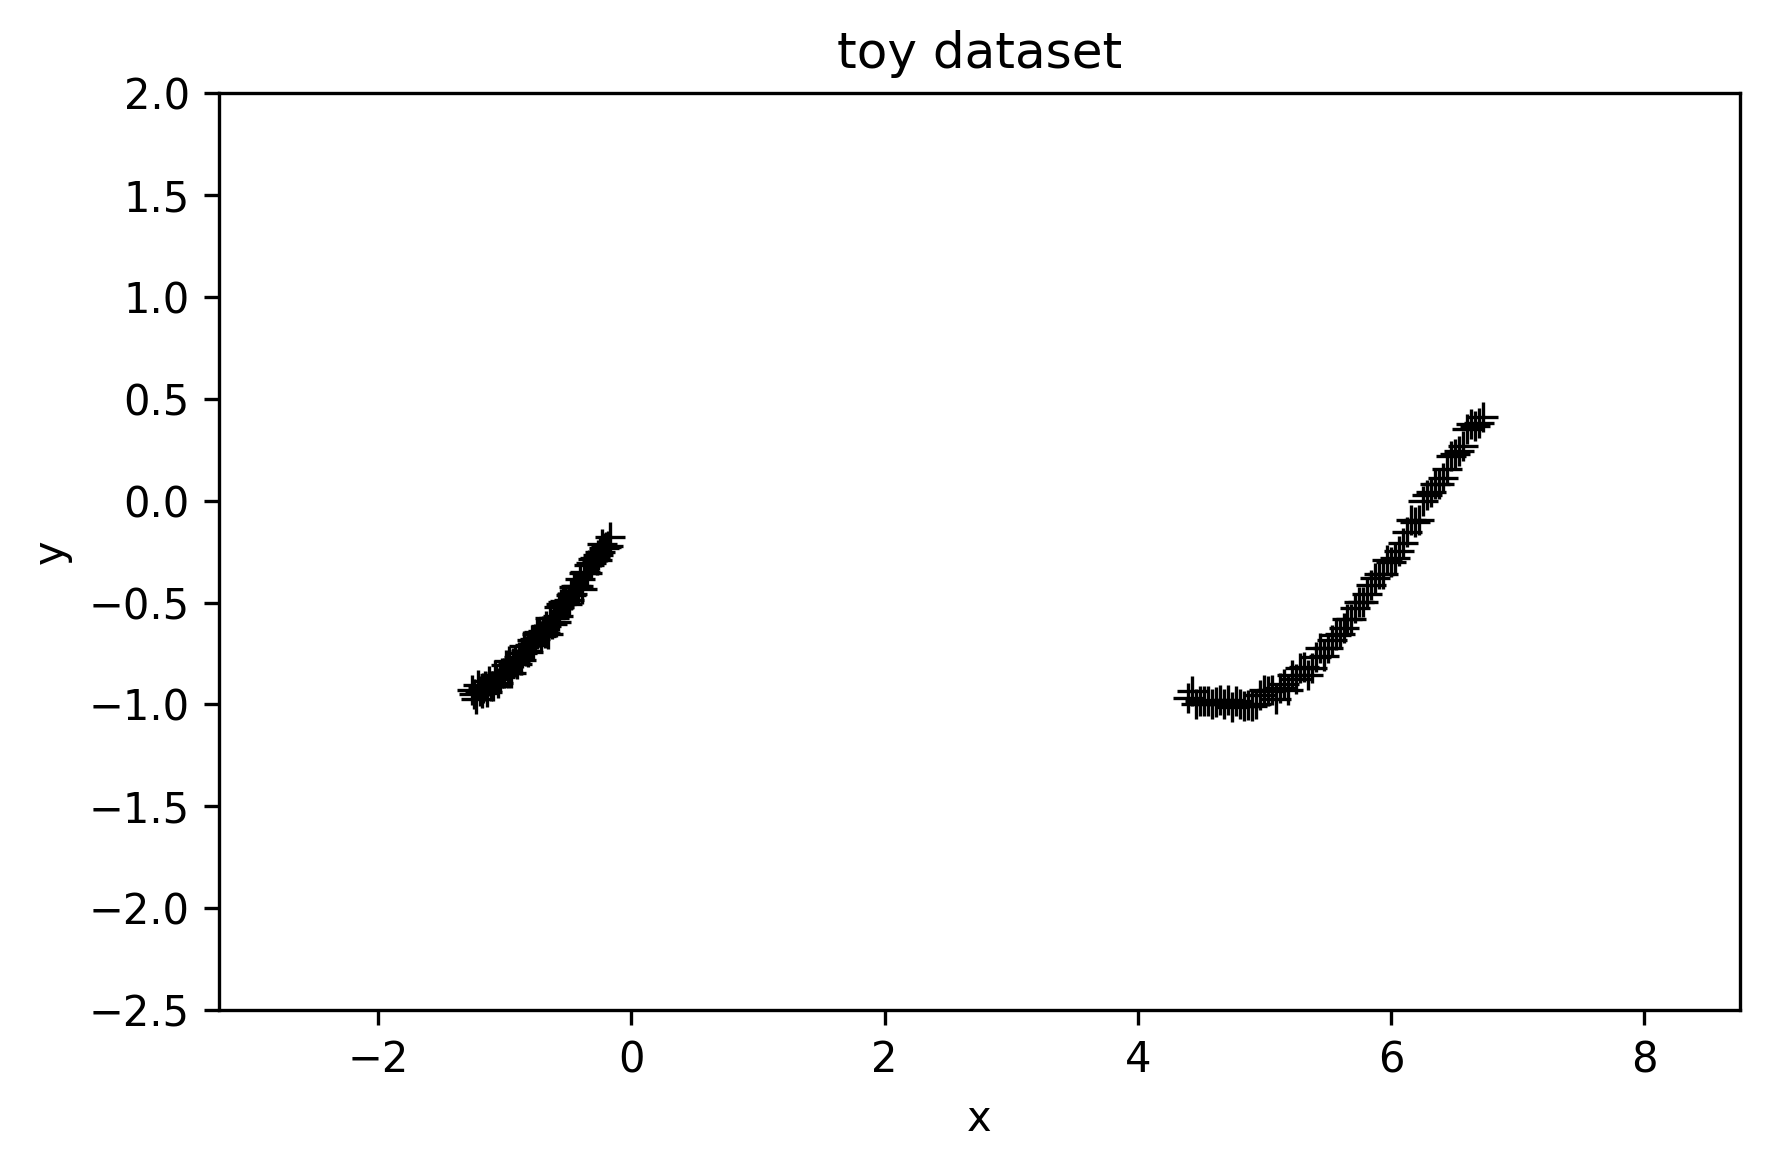

In [2]:
n_train = 150
noise_std = 0.02
start_region1 = -np.pi * 0.40
stop_region1 = -np.pi * 0.05
start_region2 = np.pi * 1.4
stop_region2 = np.pi * 2.15
ood = 2.0

# Training data
interval1 = np.abs(np.abs(start_region1) - np.abs(stop_region1))
interval2 = np.abs(start_region2 - stop_region2)
x1 = np.arange(start_region1, stop_region1, interval1 / (n_train / 2))
x2 = np.arange(start_region2, stop_region2, interval2 / (n_train / 2))
dat = np.concatenate((x1,x2))
eps = np.random.normal(loc=0, scale=noise_std, size=n_train)
gt = np.sin(dat) + eps

plt.figure(figsize=(6,4))
plt.scatter(dat, gt, color='k', marker='+', s=50, linewidth=0.8, zorder=1)
plt.title('toy dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.ylim([-2.5, 2.0])
plt.xlim([start_region1 - ood, stop_region2 + ood])
plt.tight_layout()

# Train a small neural network with IVON

In [87]:
# the net
class MLP(nn.Module):
    def __init__(self, in_dim):
        super(MLP, self).__init__()
        self.in_dim = in_dim
        self.out_dim = 2
        self.act = nn.Tanh()
        self.hidden1 = nn.Linear(self.in_dim, 100)
        self.hidden2 = nn.Linear(100, 100)
        self.out = nn.Linear(100, 2)

    def forward(self, x):
        x = x.view(-1, self.in_dim)
        x = self.act(self.hidden1(x))
        x = self.out(self.act(self.hidden2(x)))
        xpos = nn.Softplus()(x[:,1])
        return torch.vstack([x[:,0], xpos]).T

# loss function is negative log-likelihood of Gaussian output of network
def avneg_loglik_gaussian(mu, y, tau):
    logliks = 0.5 * (-math.log(2 * math.pi) + torch.log(tau) - tau * (y - mu).square())
    avneg_loglik = - torch.mean(logliks)
    return avneg_loglik


# define model, optimizer, and LR scheduler
model = MLP(in_dim=1)

optimizer = ivon.IVON(
    model.parameters(),
    lr = 0.1,
    ess = n_train * 100,
    beta1 = 0.9,
    beta2 = 0.9999,
    weight_decay = 1e-4,
    hess_init = 0.1,
    mc_samples = 1)

n_steps = 25000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=0.0, T_max=n_steps)

# full batch training for 25000 epochs
X, y = torch.from_numpy(dat).to(dtype=torch.get_default_dtype()), torch.from_numpy(gt)

for i in range(n_steps + 1):
    with optimizer.sampled_params(train=True):
        optimizer.zero_grad()
        out = model(X)
        l = avneg_loglik_gaussian(out[:,0], y, out[:,1])
        l.backward()

    if i % 1000 == 0:
        print('Step %6d: loss=%f' % (i, l.item()))

    optimizer.step()
    scheduler.step()

Step      0: loss=1.364166
Step   1000: loss=0.488623
Step   2000: loss=0.749467
Step   3000: loss=-0.578601
Step   4000: loss=-0.858723
Step   5000: loss=-0.998723
Step   6000: loss=-1.173571
Step   7000: loss=-1.208197
Step   8000: loss=-1.500519
Step   9000: loss=-1.565467
Step  10000: loss=-1.594580
Step  11000: loss=-1.667899
Step  12000: loss=-1.749706
Step  13000: loss=-1.765683
Step  14000: loss=-1.667330
Step  15000: loss=-1.791102
Step  16000: loss=-1.846803
Step  17000: loss=-1.847356
Step  18000: loss=-1.840771
Step  19000: loss=-1.813033
Step  20000: loss=-1.890112
Step  21000: loss=-1.897400
Step  22000: loss=-1.887007
Step  23000: loss=-1.902676
Step  24000: loss=-1.904578
Step  25000: loss=-1.911131


In [88]:
n_test = 100
start_test = start_region1 - ood
stop_test = stop_region2 + ood
interval_test = np.abs(start_test-stop_test)
X_test = torch.Tensor(np.arange(start_test, stop_test, interval_test / (n_test)))

samples = []

for i in range(1000):
    with optimizer.sampled_params(train=False):
        out = model(X_test)
        mean = out[:, 0].detach().numpy()
        prec = out[:, 1].detach().numpy()

    samples.append(np.random.randn(X_test.shape[0]) / np.sqrt(prec) + mean)

samples = np.vstack(samples)
mean = samples.mean(axis=0)
std = samples.std(axis=0)

# Train with AdamW

In [72]:
# define model, optimizer, and LR scheduler
model = MLP(in_dim=1)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 5e-3,
    weight_decay = 0.1)
n_steps = 25000
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=0.0, T_max=n_steps)

# full batch training for 25000 epochs
X, y = torch.from_numpy(dat).to(dtype=torch.get_default_dtype()), torch.from_numpy(gt)

for i in range(n_steps + 1):
    optimizer.zero_grad()
    out = model(X)
    l = avneg_loglik_gaussian(out[:,0], y, out[:,1])
    l.backward()

    if i % 1000 == 0:
        print('Step %6d: loss=%f' % (i, l.item()))

    optimizer.step()
    scheduler.step()

Step      0: loss=1.180095
Step   1000: loss=-1.531152
Step   2000: loss=-1.736754
Step   3000: loss=-1.796257
Step   4000: loss=-1.869038
Step   5000: loss=-1.893854
Step   6000: loss=-1.469212
Step   7000: loss=-1.902341
Step   8000: loss=-1.964012
Step   9000: loss=-1.979204
Step  10000: loss=-2.000398
Step  11000: loss=-2.022687
Step  12000: loss=-2.046878
Step  13000: loss=-2.067063
Step  14000: loss=-2.096437
Step  15000: loss=-2.118564
Step  16000: loss=-2.138026
Step  17000: loss=-2.154102
Step  18000: loss=-2.166988
Step  19000: loss=-2.176966
Step  20000: loss=-2.186191
Step  21000: loss=-2.195281
Step  22000: loss=-2.202602
Step  23000: loss=-2.208005
Step  24000: loss=-2.210846
Step  25000: loss=-2.211421


In [73]:
n_test = 100
start_test = start_region1 - ood
stop_test = stop_region2 + ood
interval_test = np.abs(start_test-stop_test)
X_test = torch.Tensor(np.arange(start_test, stop_test, interval_test / (n_test)))

samples_sgd = []

for i in range(10000):
    out = model(X_test)
    m = out[:, 0].detach().numpy()
    prec = out[:, 1].detach().numpy()

    samples_sgd.append(np.random.randn(X_test.shape[0]) / np.sqrt(prec) + m)

samples_sgd = np.vstack(samples_sgd)
mean_sgd = samples_sgd.mean(axis=0)
std_sgd = samples_sgd.std(axis=0)

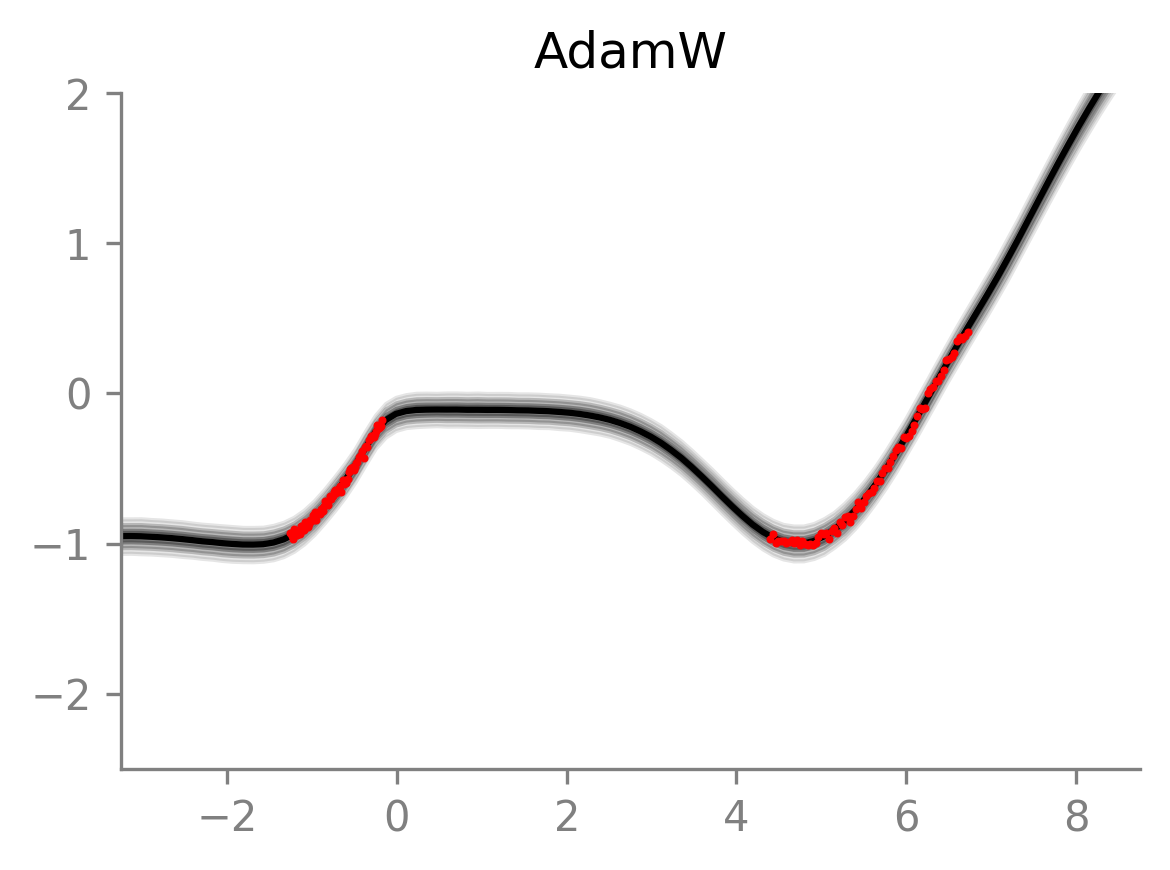

In [76]:
fig, ax = plt.subplots(figsize=(4, 3))

#plt.figure(figsize=(6,4))
#plt.title('predictive distribution')
#plt.xlabel('x')
#plt.ylabel('y')
plt.ylim([-2.5, 2.0])
plt.xlim([start_region1 - ood, stop_region2 + ood])
ax.plot(X_test, mean_sgd, color='k')
ax.fill_between(np.squeeze(X_test), mean_sgd - 1 * std_sgd, mean_sgd + 1 * std_sgd, alpha=0.3, color='black')
ax.fill_between(np.squeeze(X_test), mean_sgd - 2 * std_sgd, mean_sgd + 2 * std_sgd, alpha=0.2, color='black')
ax.fill_between(np.squeeze(X_test), mean_sgd - 3 * std_sgd, mean_sgd + 3 * std_sgd, alpha=0.1, color='black')
ax.scatter(dat, gt, color='red', marker='.', s=5, linewidth=0.8, zorder=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('grey')
ax.spines['left'].set_color('grey')
ax.tick_params(color='grey', labelcolor='grey')
#ax.set_axis_off()
ax.set_title('AdamW')
fig.tight_layout()
fig.savefig('../plots/inbetween-adamw.png', bbox_inches='tight', pad_inches=0)

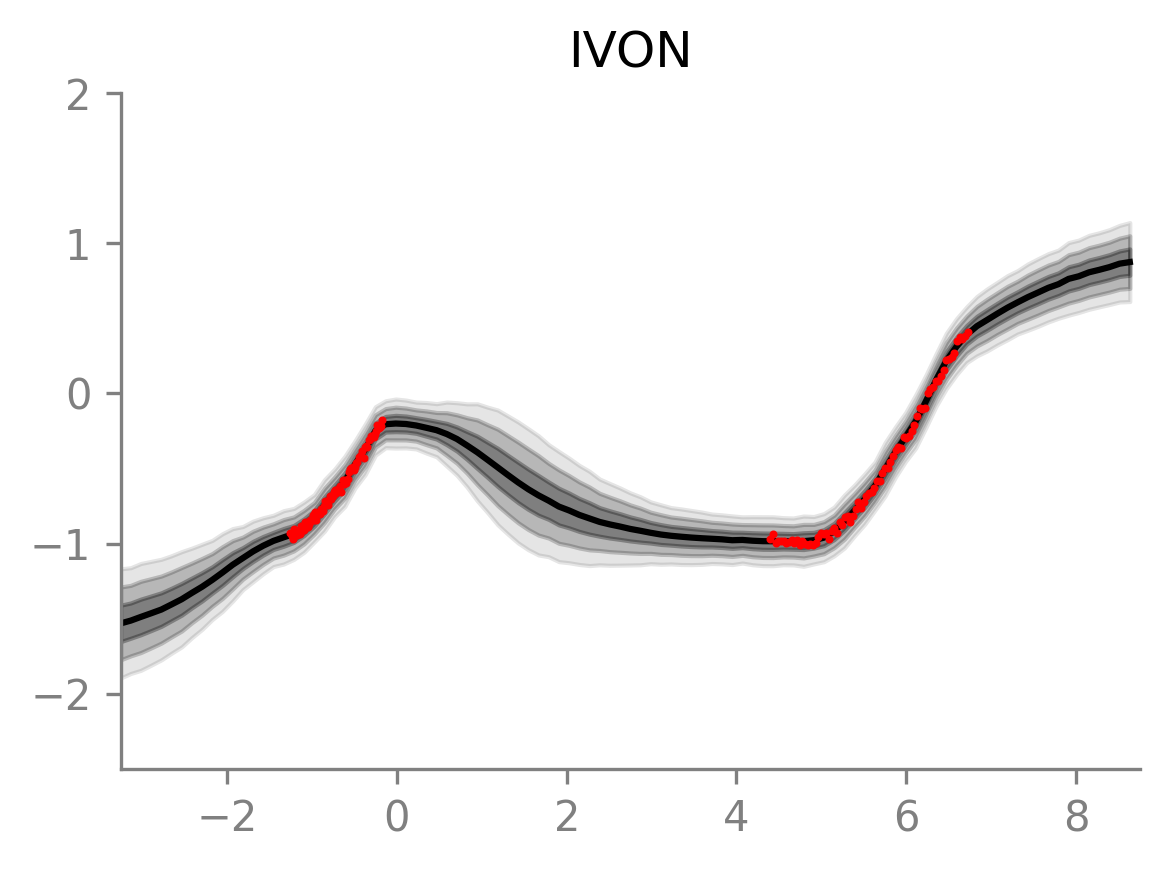

In [77]:
fig, ax = plt.subplots(figsize=(4, 3))

#ax.scatter(dat, gt, color='k', marker='+', s=50, linewidth=0.8, zorder=1)
plt.ylim([-2.5, 2.0])
plt.xlim([start_region1 - ood, stop_region2 + ood])
ax.plot(X_test, mean, color='k')
ax.fill_between(np.squeeze(X_test), mean - 1 * std, mean + 1 * std, alpha=0.3, color='black')
ax.fill_between(np.squeeze(X_test), mean - 2 * std, mean + 2 * std, alpha=0.2, color='black')
ax.fill_between(np.squeeze(X_test), mean - 3 * std, mean + 3 * std, alpha=0.1, color='black')
ax.scatter(dat, gt, color='red', marker='.', s=5, linewidth=0.8, zorder=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('grey')
ax.spines['left'].set_color('grey')
ax.tick_params(color='grey', labelcolor='grey')
#ax.set_axis_off()
ax.set_title('IVON')
fig.tight_layout()
fig.savefig('../plots/inbetween-ivon.png', bbox_inches='tight', pad_inches=0)

# Train with IVONLR

In [78]:
def train_model_different_optimizer_setting(optimizer: ivon.IVONLR, model: MLP):
    n_steps = 25000
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=0.0, T_max=n_steps)

    # full batch training for 25000 epochs
    X, y = torch.from_numpy(dat).to(dtype=torch.get_default_dtype()), torch.from_numpy(gt)

    losses = []
    for i in range(n_steps + 1):
        with optimizer.sampled_params(train=True):
            optimizer.zero_grad()
            out = model(X)
            l = avneg_loglik_gaussian(out[:,0], y, out[:,1])
            l.backward()

        if i % 1000 == 0:
            print('Step %6d: loss=%f' % (i, l.item()))
            losses.append(l.item())

        optimizer.step()
        scheduler.step()
    
    return model, losses

In [82]:
def plot_uncertainty_region(model1: MLP, optimizer: ivon.IVONLR, title:str, rank: int):
    n_test = 100
    start_test = start_region1 - ood
    stop_test = stop_region2 + ood
    interval_test = np.abs(start_test-stop_test)
    X_test = torch.Tensor(np.arange(start_test, stop_test, interval_test / (n_test)))

    samples = []

    for i in range(1000):
        with optimizer.sampled_params(train=False):
            out = model1(X_test)
            mean = out[:, 0].detach().numpy()
            prec = out[:, 1].detach().numpy()

        samples.append(np.random.randn(X_test.shape[0]) / np.sqrt(prec) + mean)

    samples = np.vstack(samples)
    mean = samples.mean(axis=0)
    std = samples.std(axis=0)
    
    fig, ax = plt.subplots(figsize=(4, 3))
    
    plt.ylim([-2.5, 2.0])
    plt.xlim([start_region1 - ood, stop_region2 + ood])
    ax.plot(X_test, mean, color='k')
    ax.fill_between(np.squeeze(X_test), mean - 1 * std, mean + 1 * std, alpha=0.3, color='black')
    ax.fill_between(np.squeeze(X_test), mean - 2 * std, mean + 2 * std, alpha=0.2, color='black')
    ax.fill_between(np.squeeze(X_test), mean - 3 * std, mean + 3 * std, alpha=0.1, color='black')
    ax.scatter(dat, gt, color='red', marker='.', s=5, linewidth=0.8, zorder=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('grey')
    ax.spines['left'].set_color('grey')
    ax.tick_params(color='grey', labelcolor='grey')
    ax.set_title(f'IVONLR - rank={rank}')
    fig.tight_layout()
    fig.savefig(f'../plots/{title}.png', bbox_inches='tight', pad_inches=0)

In [85]:
def plot_uncertainty_region_epistemic(model1, optimizer, title, rank):
    n_test = 100
    start_test = start_region1 - ood
    stop_test = stop_region2 + ood
    X_test = torch.Tensor(np.linspace(start_test, stop_test, n_test))

    mean_samples = []
    for _ in range(1000):
        with optimizer.sampled_params(train=False):
            out = model1(X_test)
            mean_samples.append(out[:, 0].detach().cpu().numpy())

    mean_samples = np.vstack(mean_samples)
    mean = mean_samples.mean(axis=0)
    std = mean_samples.std(axis=0)   # <-- epistemic std

    fig, ax = plt.subplots(figsize=(4, 3))
    ax.set_xlim([start_test, stop_test])
    ax.set_ylim([-2.5, 2.0])

    ax.plot(X_test, mean, color='k')
    ax.fill_between(np.squeeze(X_test), mean-std, mean+std, alpha=0.3, color='black')
    ax.fill_between(np.squeeze(X_test), mean-2*std, mean+2*std, alpha=0.2, color='black')
    ax.fill_between(np.squeeze(X_test), mean-3*std, mean+3*std, alpha=0.1, color='black')

    ax.scatter(dat, gt, color='red', marker='.', s=5, linewidth=0.8, zorder=2)
    ax.set_title(f'IVONLR epistemic - rank={rank}')
    fig.tight_layout()
    fig.savefig(f'../plots/{title}.png', bbox_inches='tight', pad_inches=0)


In [92]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def measure_epistemic_id_ood(model, optimizer, start_region1, stop_region2, ood, n_test=200, n_samples=500):
    # grid
    start_test = start_region1 - ood
    stop_test = stop_region2 + ood
    X_test = torch.tensor(np.linspace(start_test, stop_test, n_test), dtype=torch.float32)

    # collect mean predictions under weight samples
    mean_samples = []
    for _ in range(n_samples):
        with optimizer.sampled_params(train=False):
            out = model(X_test)
            mean_samples.append(out[:, 0].detach().cpu().numpy())
    mean_samples = np.vstack(mean_samples)  # [S, n_test]

    epistemic_std = mean_samples.std(axis=0)  # std over samples at each x

    x_np = X_test.cpu().numpy()
    ood_mask = (x_np < start_region1) | (x_np > stop_region2)
    id_mask = ~ood_mask

    U_ood = float(epistemic_std[ood_mask].mean())
    U_id  = float(epistemic_std[id_mask].mean())
    return U_id, U_ood


In [93]:
# Different rank
rank_losses = {}
rank_metrics = {}

for rank in range(8):
    print(f"Training with rank={rank}")
    model = MLP(in_dim=1)
    optimizer = ivon.IVONLR(
            model.parameters(),
            lr=0.1,
            ess=n_train*100,
            beta1=0.9,
            beta2=0.9999,
            weight_decay=1e-4,
            hess_init=0.1,
            mc_samples=1,
            rank=rank,
            low_rank_init=1e-2,
        )
    trained_model, losses = train_model_different_optimizer_setting(
        optimizer=optimizer,
        model=model,
    )
    # rank_losses[rank] = losses
    # plot_uncertainty_region(
    #     model1=trained_model,
    #     optimizer=optimizer,
    #     title=f'inbetween-ivonlr-rank{rank}',
    #     rank=rank
    # )
    # plot_uncertainty_region_epistemic(
    #     model1=trained_model,
    #     optimizer=optimizer,
    #     title=f'inbetween-ivonlr-epistemic-rank{rank}',
    #     rank=rank
    # )
    U_id, U_ood = measure_epistemic_id_ood(
        trained_model, optimizer,
        start_region1=start_region1,
        stop_region2=stop_region2,
        ood=ood,
        n_test=300,
        n_samples=500,
    )

    rank_metrics[rank] = {"U_id": U_id, "U_ood": U_ood}
    print(f"rank={rank}: epistemic U_id={U_id:.4f}, U_ood={U_ood:.4f}")

Training with rank=0
Step      0: loss=1.467421
Step   1000: loss=-0.073631
Step   2000: loss=-0.508599
Step   3000: loss=-0.756161
Step   4000: loss=-0.949313
Step   5000: loss=-0.538400
Step   6000: loss=-1.126157
Step   7000: loss=-1.395530
Step   8000: loss=-1.449970
Step   9000: loss=-1.431482
Step  10000: loss=-1.607223
Step  11000: loss=-1.606222
Step  12000: loss=-1.671123
Step  13000: loss=-1.740296
Step  14000: loss=-1.718639
Step  15000: loss=-1.811296
Step  16000: loss=-1.705021
Step  17000: loss=-1.840253
Step  18000: loss=-1.767558
Step  19000: loss=-1.868848
Step  20000: loss=-1.901987
Step  21000: loss=-1.887419
Step  22000: loss=-1.845923
Step  23000: loss=-1.879016
Step  24000: loss=-1.906000
Step  25000: loss=-1.869849
rank=0: epistemic U_id=0.0476, U_ood=0.0534
Training with rank=1
Step      0: loss=1.319689
Step   1000: loss=0.051865
Step   2000: loss=-0.201371
Step   3000: loss=-0.530166
Step   4000: loss=-0.981940
Step   5000: loss=-0.420988
Step   6000: loss=-1.

In [94]:
rank_metrics

{0: {'U_id': 0.04755527526140213, 'U_ood': 0.0534205324947834},
 1: {'U_id': 0.04241352528333664, 'U_ood': 0.059738799929618835},
 2: {'U_id': 0.0761190876364708, 'U_ood': 0.04914402961730957},
 3: {'U_id': 0.051795653998851776, 'U_ood': 0.04683004692196846},
 4: {'U_id': 0.04417242854833603, 'U_ood': 0.041155070066452026},
 5: {'U_id': 0.04340721294283867, 'U_ood': 0.05224821716547012},
 6: {'U_id': 0.06977285444736481, 'U_ood': 0.044318586587905884},
 7: {'U_id': 0.05806310474872589, 'U_ood': 0.044324420392513275}}

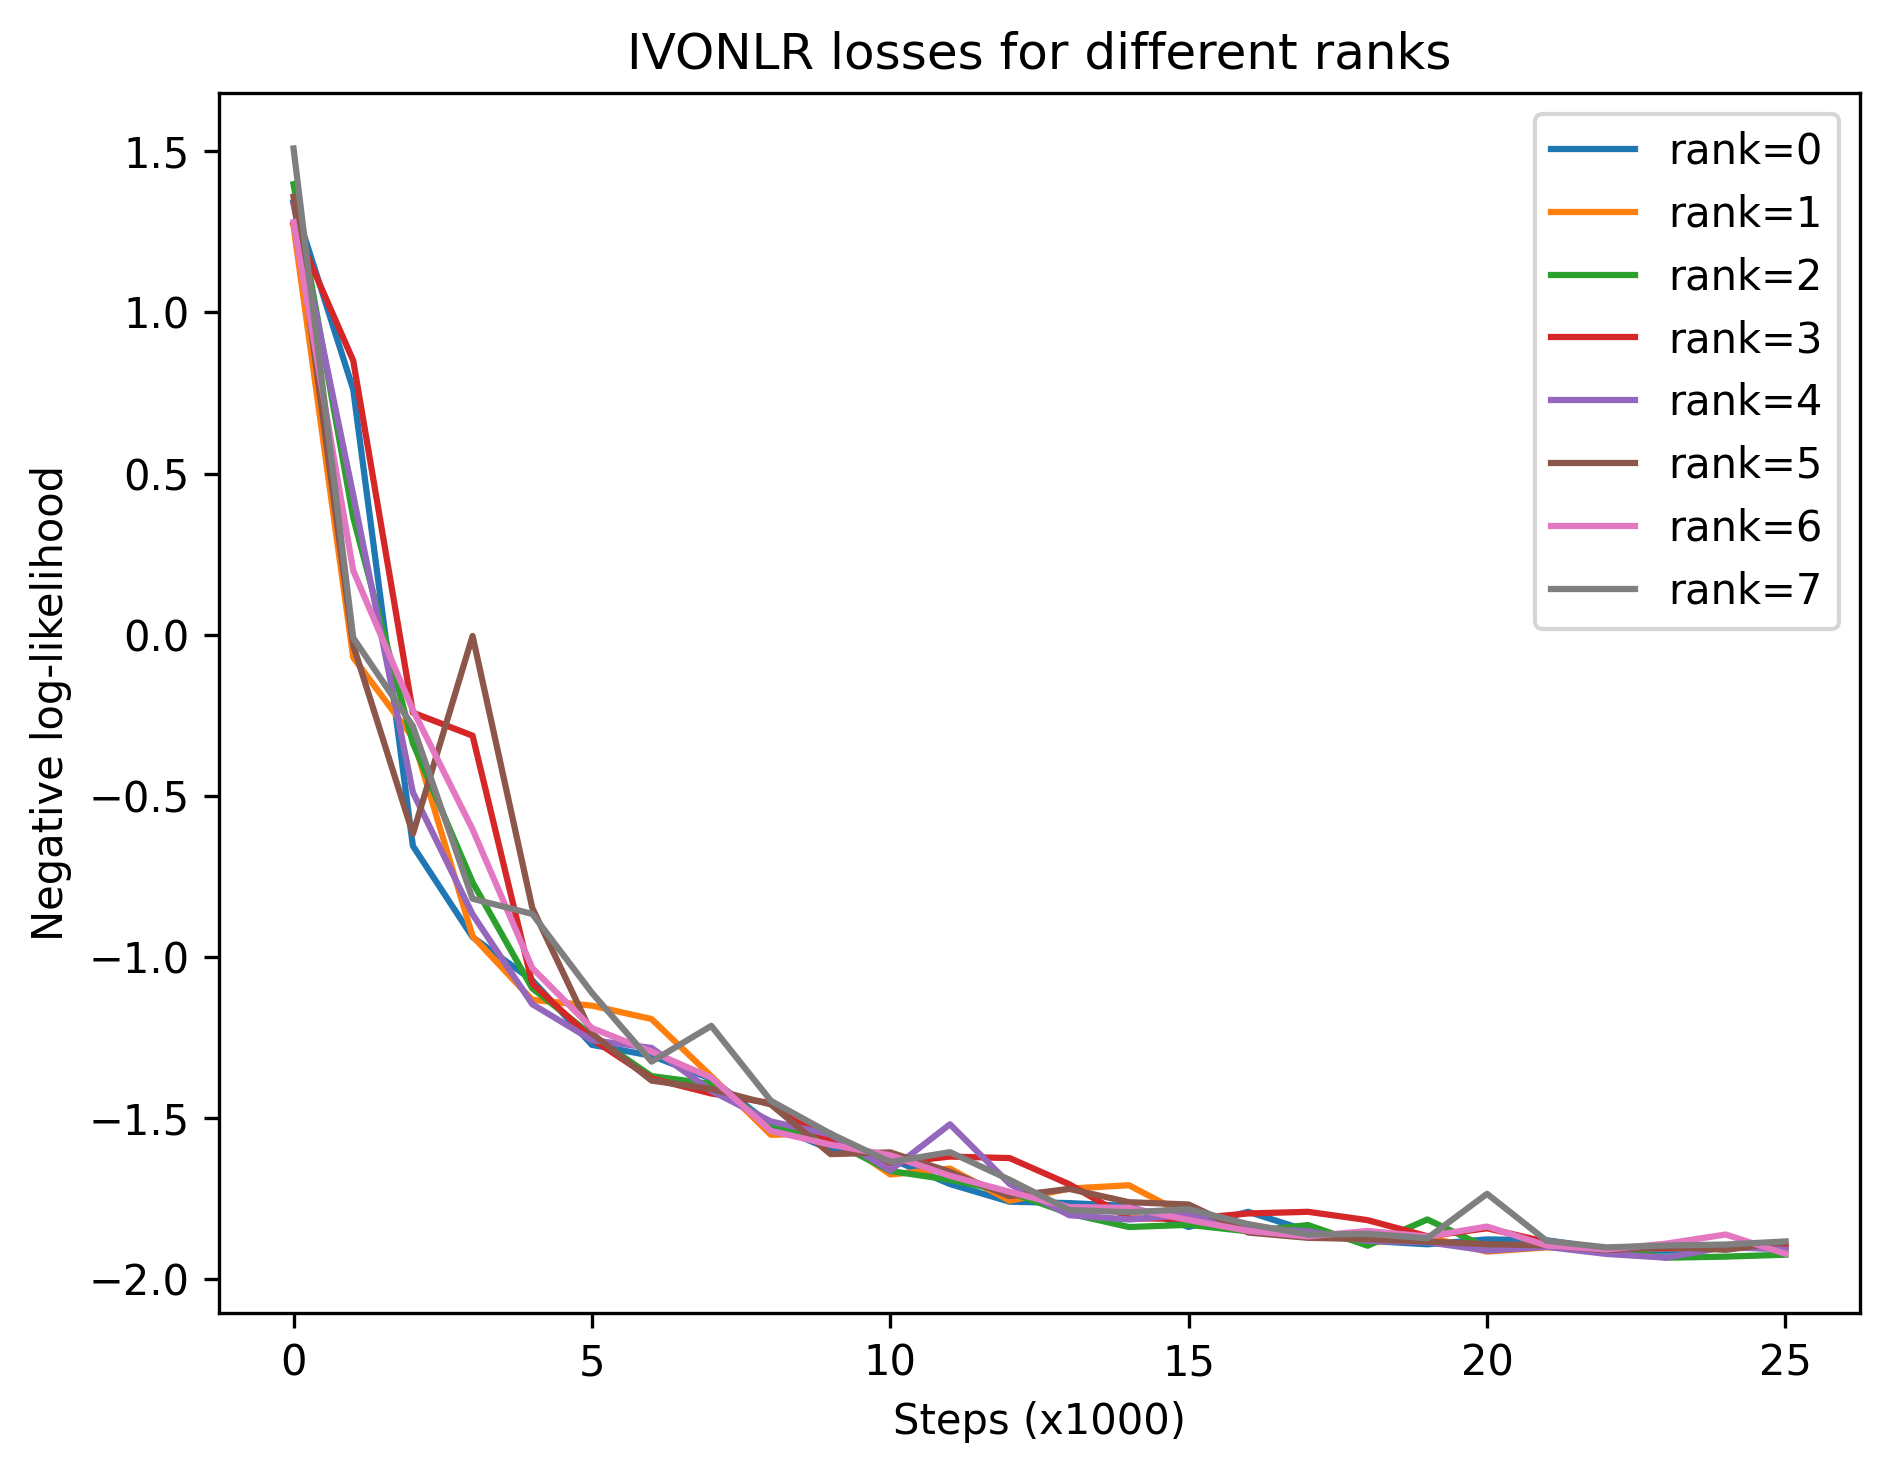

In [69]:
for rank, losses in rank_losses.items():
    plt.plot(np.arange(0, len(losses)), losses, label=f'rank={rank}')
plt.xlabel('Steps (x1000)')
plt.ylabel('Negative log-likelihood')
plt.legend()
plt.tight_layout()
plt.title('IVONLR losses for different ranks')
plt.savefig('../plots/inbetween-ivonlr-losses.png', bbox_inches='tight', pad_inches=0)
plt.show()

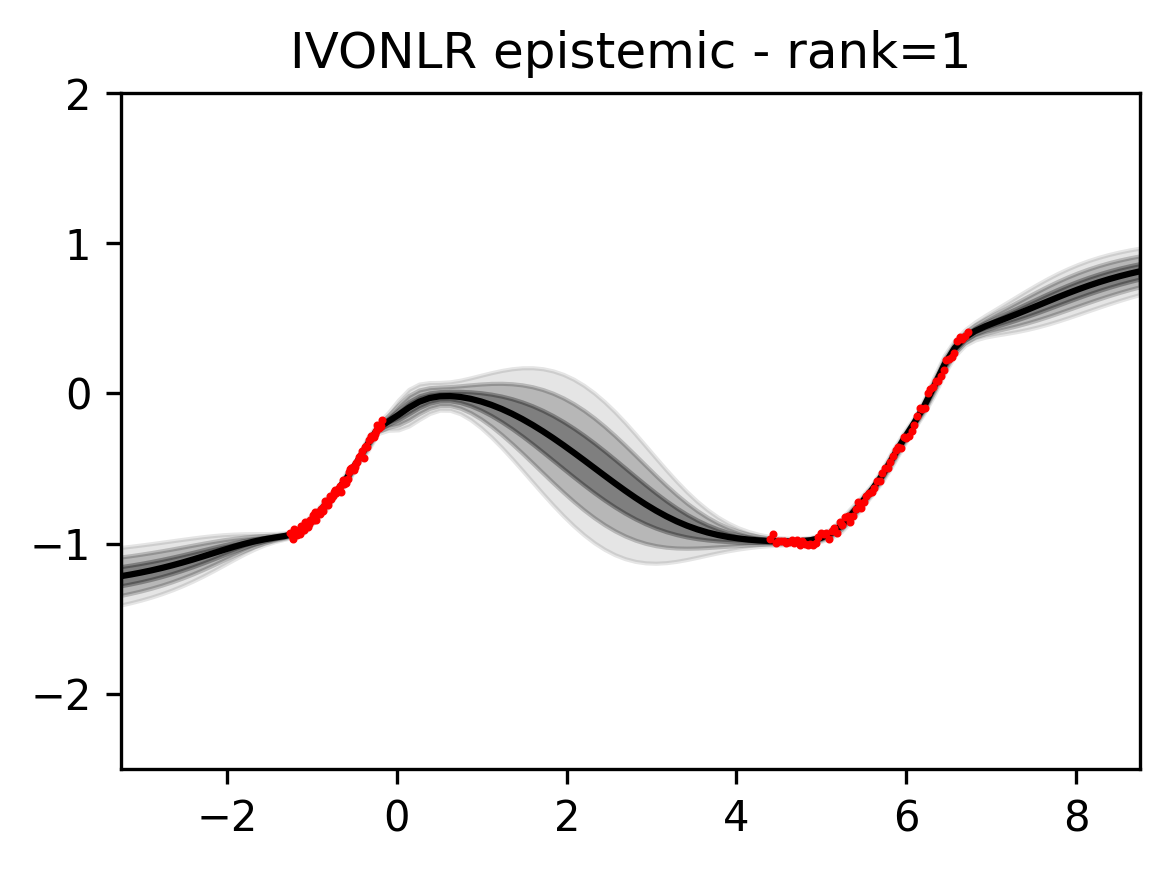

In [89]:
plot_uncertainty_region_epistemic(
        model1=model,
        optimizer=optimizer,
        title=f'inbetween-ivon-epistemic',
        rank=rank
    )